# Instalando Bibliotecas

In [ ]:
pip uninstall catboost

In [265]:
import numpy as np
import pandas as pd
import datetime as dt
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf as _plot_acf
from statsmodels.graphics.tsaplots import plot_pacf as _plot_pacf
from sklearn.metrics import ConfusionMatrixDisplay

import statsmodels
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
import pmdarima as pm
from prophet import Prophet
from catboost import CatBoostClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.svm import SVC

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    TimeSeriesSplit,
    StratifiedShuffleSplit,
    StratifiedKFold
)

from statsmodels.tsa.stattools import adfuller
from sklearn.datasets import fetch_olivetti_faces
from sklearn.cluster import KMeans

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    RocCurveDisplay,
    balanced_accuracy_score,
    f1_score
)
from sklearn.exceptions import UndefinedMetricWarning
from lightgbm import LGBMClassifier


# Trazendo e transformando dados

In [ ]:
ibov = pd.read_csv('IbovDef.csv', sep=',')
ibov.shape

(6388, 7)

## Definindo Funções

In [25]:
def vol(valor):
    valor = str(valor).strip()

    if valor == "" or valor.lower() == "nan":
        return 0

    multiplicador = 1
    if valor.endswith("K"):
        multiplicador = 1000
        valor = valor[:-1]
    elif valor.endswith("M"):
        multiplicador = 1000000
        valor = valor[:-1]
    elif valor.endswith("B"):
        multiplicador = 1000000000
        valor = valor[:-1]

    valor = valor.replace(".", "").replace(",", ".", valor.count(".")-1)
    try:
        return float(valor) * multiplicador
    except ValueError:
        return 0.0

def direcao(var):
    if var > 0:
        return 1
    elif var < 0:
        return 0
    else:
        return 2

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return mae, mse, mape

def print_metrics(metrics):
    mae, mse, mape = metrics
    print(f"MAE: {mae}")
    print(f"MSE: {mse}")
    print(f"MAPE: {mape:.2f} %")

def substitui_dots(s):
    parts = s.split(".")
    last = parts[-1]
    if len(last) == 3:
        numeric = "".join(parts)
        return float(numeric) 
    else:
        left = "".join(parts[:-1])
        right = last.ljust(3, "0")
        numeric = left + right
        return float(numeric)

def prepara_metricas(df):
    for w in [3, 7, 14, 21, 30]: #Médias móveis
        df[f"mm_{w}"] = df["Último"].rolling(w).mean() 
    
    for w in [3, 7, 14, 21, 30]: #Medianas móveis
        df[f"mn_{w}"] = df["Último"].rolling(w).median() 

    for w in [5, 10, 15, 20]: #Volatilidade
        df[f"var_{w}"] = df["Último"].rolling(w).std()

    for w in [5, 10, 15, 20]: #Volume
        df[f"vol_{w}"] = df["Último"].rolling(w).mean()
        

    df["Target"] = (df["Último"].shift(-1) > df["Último"]).astype(int)
    df['Var'] = df['Último'] - df['Abertura']
    df['delta'] = df['Último'].shift(1)
    df["dif_mn3"] = df["Último"] - df["mn_3"]
    df["dif_mn7"] = df["Último"] - df["mn_7"]
    df["dif_mn14"] = df["Último"] - df["mn_14"]
    df["dif_mn21"] = df["Último"] - df["mn_21"]
    df["dif_mn30"] = df["Último"] - df["mn_30"]

    return df

## Manipulando dados

In [254]:
ibov = pd.read_csv('IbovDef.csv', sep=',')
ibov.shape

ibov["Var%"] = ibov["Var%"].str.replace("%", "").str.replace(",", ".").astype(float)

for col in ['Último', 'Abertura', 'Máxima', 'Mínima']:
    ibov[col] = ibov[col].astype(str).apply(substitui_dots)

ibov['Data'] = pd.to_datetime(ibov['Data'].astype(str), format='%d.%m.%Y')
ibov = ibov.sort_values(by="Data", ascending=True)
ibov["dayofweek"] = ibov["Data"].dt.dayofweek


ibov["Vol."] = ibov["Vol."].apply(vol)
ibov["Direção"] = ibov["Var%"].apply(direcao)
ibov = prepara_metricas(ibov)

ibov = ibov[ibov["Direção"] != 2]
ibov = ibov.dropna(subset=['mm_30'])

ibov['diff_ultimo'] = ibov['Último'].diff()
ibov['mm_diff'] = ibov['diff_ultimo'].rolling(365).mean()
ibov['std_diff'] = ibov['diff_ultimo'].rolling(365).std()

# periodos_excluir = [
#     ('2020-01-01', '2020-08-31'),
#     ('2015-09-01', '2016-03-31'),
#     ('2008-09-01', '2009-05-31')
#     ]

# for inicio, fim in periodos_excluir:
#     mask = (ibov["Data"] >= inicio) & (ibov["Data"] <= fim)
#     ibov.loc[mask, "Último"] = ibov.loc[mask, "mn_30"]


ibov = ibov.reset_index(drop=True)
ibov.head()

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%,dayofweek,Direção,mm_3,...,Var,delta,dif_mn3,dif_mn7,dif_mn14,dif_mn21,dif_mn30,diff_ultimo,mm_diff,std_diff
0,2000-02-14,17819.0,18083.0,18264.0,17746.0,772930000.0,-1.46,0,0,18168.666667,...,-264.0,18083.0,-264.0,-307.0,181.0,349.0,726.0,NaN,NaN,NaN
1,2000-02-15,17921.0,17818.0,17932.0,17451.0,919500000.0,0.57,1,1,17941.000000,...,103.0,17819.0,0.0,-205.0,51.0,451.0,780.0,102.0,NaN,NaN
2,2000-02-16,18112.0,17921.0,18247.0,17743.0,111360000.0,1.07,2,1,17950.666667,...,191.0,17921.0,191.0,0.0,185.5,642.0,874.5,191.0,NaN,NaN
3,2000-02-17,17979.0,18116.0,18297.0,17979.0,683210000.0,-0.73,3,0,18004.000000,...,-137.0,18112.0,0.0,-104.0,23.5,509.0,601.5,-133.0,NaN,NaN
4,2000-02-18,17625.0,17979.0,18008.0,17489.0,733360000.0,-1.97,4,0,17905.333333,...,-354.0,17979.0,-354.0,-354.0,-330.5,0.0,161.5,-354.0,NaN,NaN


In [255]:
x = ibov[[
    #"Abertura",
    "Vol.", 
    #"mm_3", "mm_7", "mm_14", "mm_21", "mm_30",
    "dif_mn3", "dif_mn7", "dif_mn14", "dif_mn21", "dif_mn30", 
    #"mn_3", "mn_7", "mn_14", "mn_21", "mn_30", 
    #"vol_5", "vol_10", "vol_15", "vol_20", 
    "var_5", "var_10",  "var_20",
    #"Último", 
    "dayofweek",
    'diff_ultimo', 'mm_diff', 'std_diff'
]]
y = ibov["Target"]

train_size = ibov.shape[0] - 30
X_train = x.iloc[:train_size]
X_test  = x.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

print("Subiu:", list(y_train).count(1), " Desceu:", list(y_train).count(0))

#ibov.dtypes

Subiu: 3269  Desceu: 3047


### Métricas opcionais (Comentadas)

In [ ]:
# ibov["Lag1"] = ibov['Último'].shift(1)
# ibov["Lag5"] = ibov['Último'].shift(5)
# ibov["MM7"] = ibov['Último'].rolling(window=7).mean()
# ibov["Ab_x_MM7"] = ibov['Abertura'] - ibov['MM7']
# ibov["MM15"] = ibov['Último'].rolling(window=15).mean()
# ibov["MM30"] = ibov['Último'].rolling(window=30).mean()
# ibov["MM7_x_MM30"] = ibov['MM7'] - ibov['MM30']
# ibov["MM60"] = ibov['Último'].rolling(window=60).mean()
# ibov["MM30_x_MM60"] = ibov['MM30'] - ibov['MM60']
# ibov["MMVol5"] = ibov['Vol.'].rolling(window=5).mean()
# ibov["VarAbs"] = ibov['Máxima'] - ibov['Mínima']
# ibov.dropna(subset=['MM60'], inplace=True)
#ibov = ibov.sort_values(by="Data", ascending=False)

## Analisando Dados transformados

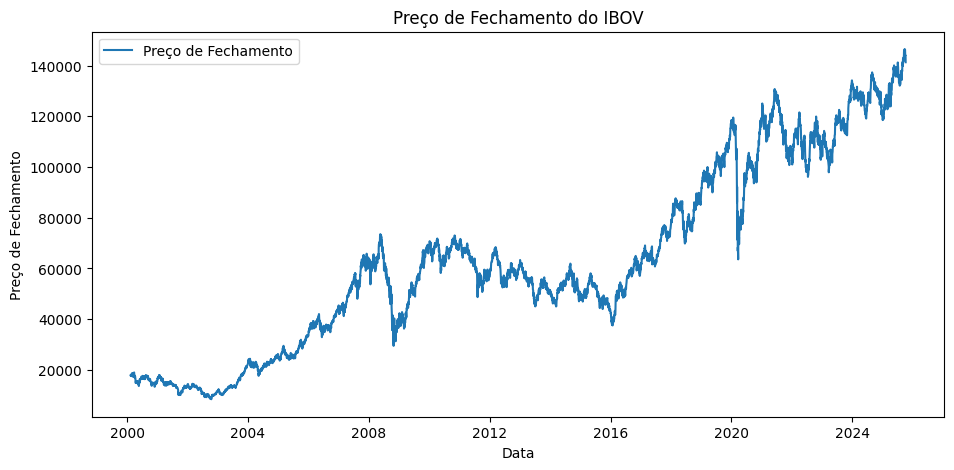

In [256]:
plt.figure(figsize=(11, 5))
plt.plot(ibov['Data'], ibov["Último"], label="Preço de Fechamento")
plt.title("Preço de Fechamento do IBOV")
plt.xlabel("Data")
plt.ylabel("Preço de Fechamento")
plt.legend()
plt.show()

## Seasonal Decompose e diferenciação

<Axes: >

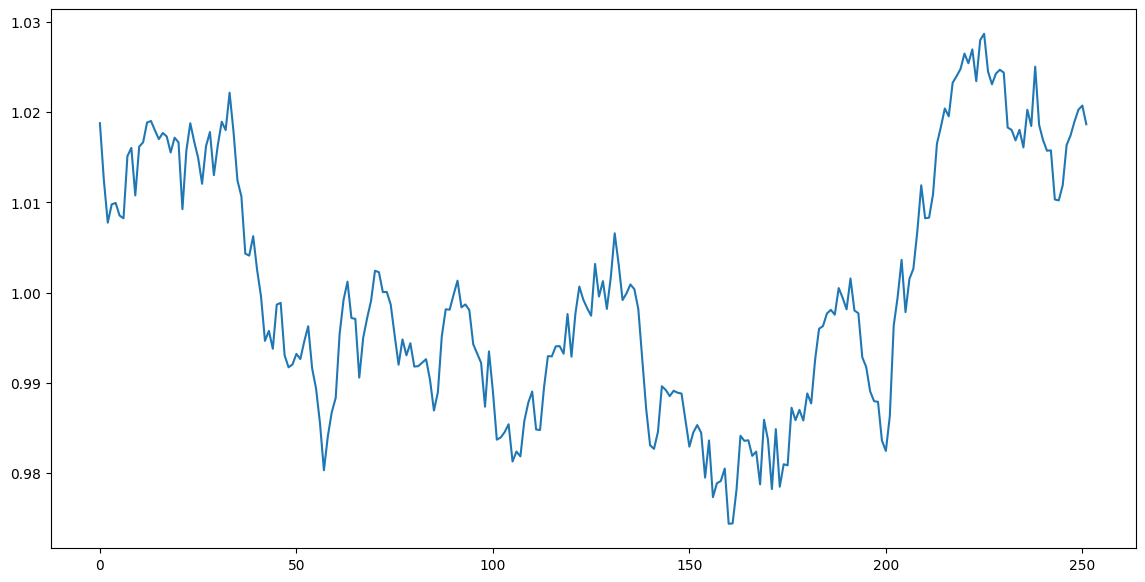

In [18]:
result = seasonal_decompose(ibov["Último"], model="multiplicative", period=252)
result.seasonal.iloc[:252].plot(figsize=(14, 7))

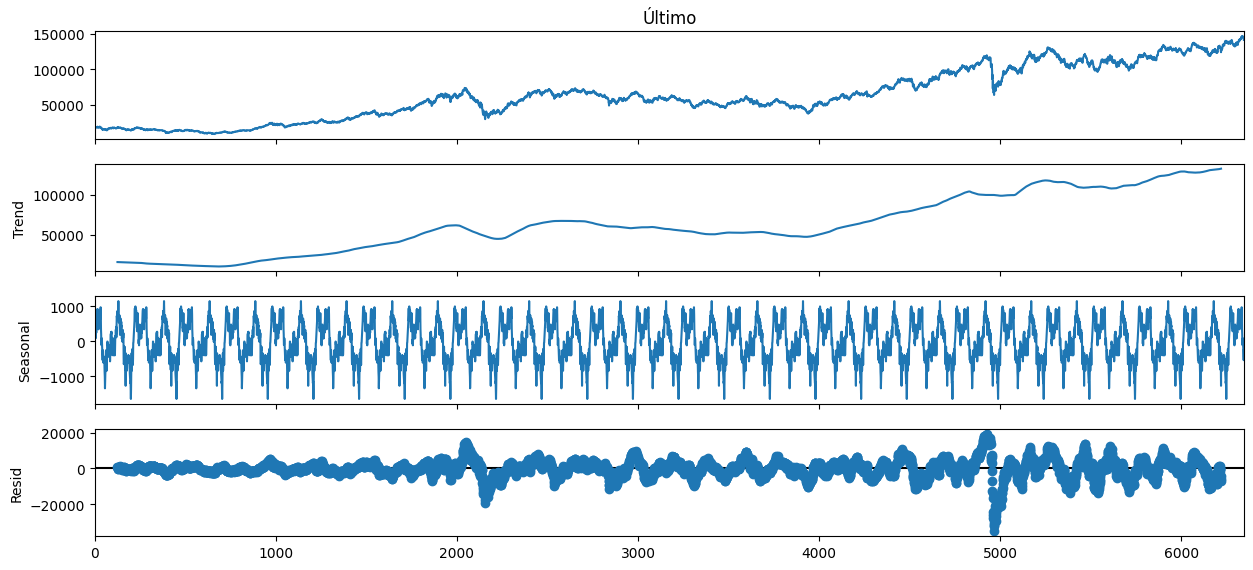

In [91]:
result = seasonal_decompose(ibov["Último"], model="additive", period=252)
fig = result.plot()
fig.set_size_inches(14, 6)

The ACF coefficients do not intercept the threshold


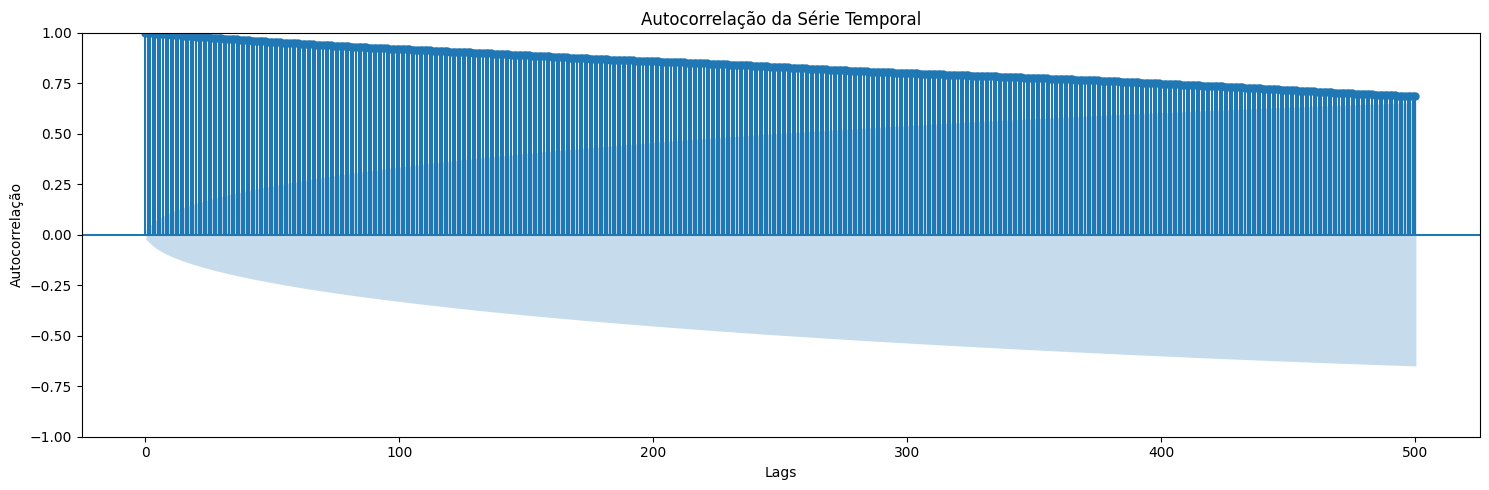

In [13]:
def plot_acf(data, lags=500, title="Autocorrelação da Série Temporal"):

    fig, ax = plt.subplots(figsize=(15, 5))
    # Get the ACF values and confidence intervals
    _plot_acf(data, lags=lags, ax=ax, alpha=0.05)
    ax.set_title(title)
    ax.set_xlabel("Lags")
    ax.set_ylabel("Autocorrelação")
    fig.set_tight_layout(True)

    acf_x = sm.tsa.acf(data, alpha=0.5, nlags=700)
    acf, ci = acf_x[:2]
    intercept_point = np.where(abs(acf) < (ci[:, 1] - acf))
    if intercept_point[0].size > 0:
        print(
            f"The ACF coefficients intercept the threshold at lag {intercept_point[0][0]}"
        )
    else:
        print("The ACF coefficients do not intercept the threshold")

plot_acf(ibov["Último"])

The PACF coefficients intercept the threshold at lag 2


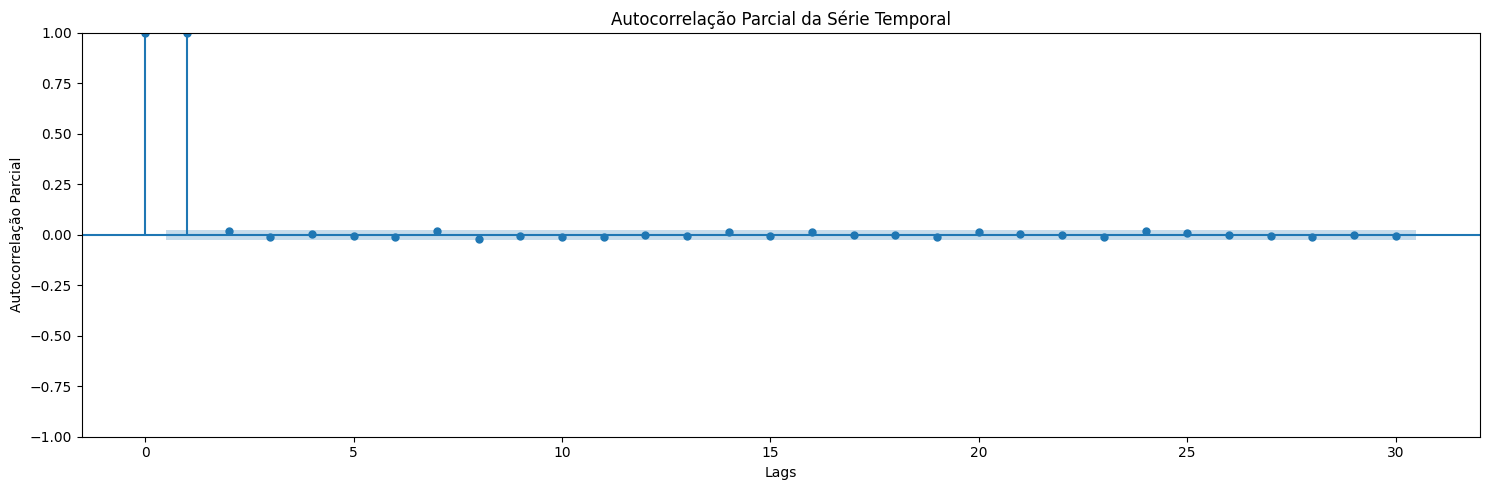

In [94]:
from statsmodels.graphics.tsaplots import plot_pacf as _plot_pacf

def plot_pacf(data, lags=30, title="Autocorrelação Parcial da Série Temporal"):

    fig, ax = plt.subplots(figsize=(15, 5))
    # Get the ACF values and confidence intervals
    _plot_pacf(data, lags=lags, ax=ax, alpha=0.05)
    ax.set_title(title)
    ax.set_xlabel("Lags")
    ax.set_ylabel("Autocorrelação Parcial")
    fig.set_tight_layout(True)

    acf_x = sm.tsa.pacf(data, alpha=0.05, nlags=lags)
    acf, ci = acf_x[:2]
    intercept_point = np.where(abs(acf) < (ci[:, 1] - acf))
    if intercept_point[0].size > 0:
        print(
            f"The PACF coefficients intercept the threshold at lag {intercept_point[0][0]}"
        )
    else:
        print("The PACF coefficients do not intercept the threshold")
        
plot_pacf(ibov["Último"])

In [95]:
adf_result = sm.tsa.adfuller(ibov["Último"])
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
print(f"Critical Values: {adf_result[4]}")

if adf_result[1] < 0.05:
    print("A série temporal é estacionária")
else:
    print("A série temporal não é estacionária")

ADF Statistic: -0.5325398622934598
p-value: 0.8855086272052622
Critical Values: {'1%': -3.431382831089674, '5%': -2.861996420816857, '10%': -2.567012949712604}
A série temporal não é estacionária


<Axes: >

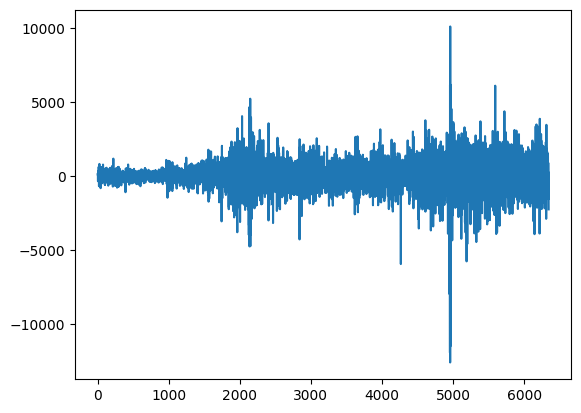

In [96]:
ibov["Último"].diff().plot()

In [97]:
adf_result = sm.tsa.adfuller(ibov["Último"].diff().dropna())
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
print(f"Critical Values: {adf_result[4]}")

if adf_result[1] < 0.05:
    print("A série temporal é estacionária")
else:
    print("A série temporal não é estacionária")

ADF Statistic: -22.162715970712785
p-value: 0.0
Critical Values: {'1%': -3.431382831089674, '5%': -2.861996420816857, '10%': -2.567012949712604}
A série temporal é estacionária


In [98]:
acf_x = sm.tsa.acf(ibov["Último"], alpha=0.05, nlags=1000)
acf, ci = acf_x[:2]

q = np.where(abs(acf) < (ci[:, 1] - acf))[0][0]

pacf_x = sm.tsa.pacf(ibov["Último"], alpha=0.05, nlags=30)
pacf, ci = pacf_x[:2]

p = np.where(abs(pacf) < (ci[:, 1] - pacf))[0][0]

d = 1
print(p, q, d)

2 536 1


In [53]:
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [54]:
model = pm.auto_arima(
    ibov["Último"],
    seasonal=True,
    m=12,
    stepwise=True,
)

print(model.summary())

seasonal_order = model.seasonal_order
print(f"Detected Seasonal Order: {seasonal_order}")

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 6346
Model:               SARIMAX(2, 1, 2)   Log Likelihood              -52979.426
Date:                Thu, 09 Oct 2025   AIC                         105968.852
Time:                        11:46:36   BIC                         106002.629
Sample:                             0   HQIC                        105980.548
                               - 6346                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.5325      0.038    -40.766      0.000      -1.606      -1.459
ar.L2         -0.7025      0.035    -20.076      0.000      -0.771      -0.634
ma.L1          1.4735      0.040     36.992      0.0

## Montagem de df treino e teste

In [87]:
train_size = ibov.shape[0] - 90
train, test = ibov[:train_size], ibov[train_size:]
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)
def create_features(df):
    df["Data"] = pd.to_datetime(df["Data"])
    df["year"] = df["Data"].dt.year
    df["month"] = df["Data"].dt.month
    df["day"] = df["Data"].dt.day
    df["dayofweek"] = df["Data"].dt.dayofweek
    df["delta1"] = df["Último"].diff().shift(-1)
    df["delta5"] = df["Último"].diff().shift(-5)
    df['Var%'] = df['Var%']
    df['Vol.'] = df['Vol.']
    df['Target'] = df['Target']
    df['Direção'] = df['Direção']
    for w in [3, 7, 14, 21, 30]: #Médias móveis
        df[f"mm_{w}"] = df[f"mm_{w}"]
    for w in [5, 10, 20]: #Volatilidade
        df[f"vol_{w}"] = df[f"vol_{w}"]
    df['dif_mm3'] = df['dif_mm3']
    df["daily_return"] = ((df["Último"] - df["Abertura"]) / df["Abertura"]).shift(1)
    return df

train = create_features(train)
test = create_features(test)

FEATURES = ["year", "month", "day", "dayofweek", "Abertura", "daily_return", "Vol.", "mm_3", "mm_7", "mm_14", "mm_21", "mm_30", "vol_5", "vol_10", "vol_20", "dif_mm3", "Var%", "Último"]
TARGET = "Target"

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

train.head(5)

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%,Direção,mm_3,dif_mm3,...,Target,Var,delta,year,month,day,dayofweek,delta1,delta5,daily_return
0,2000-02-14,17819.0,18083.0,18264.0,17746.0,772930000.0,-1.46,0,18168.666667,-349.666667,...,1,-264.0,18083.0,2000,2,14,0,102.0,75.0,NaN
1,2000-02-15,17921.0,17818.0,17932.0,17451.0,919500000.0,0.57,1,17941.000000,-20.000000,...,1,103.0,17819.0,2000,2,15,1,191.0,-211.0,-0.014599
2,2000-02-16,18112.0,17921.0,18247.0,17743.0,111360000.0,1.07,1,17950.666667,161.333333,...,0,191.0,17921.0,2000,2,16,2,-133.0,344.0,0.005781
3,2000-02-17,17979.0,18116.0,18297.0,17979.0,683210000.0,-0.73,0,18004.000000,-25.000000,...,0,-137.0,18112.0,2000,2,17,3,-354.0,-57.0,0.010658
4,2000-02-18,17625.0,17979.0,18008.0,17489.0,733360000.0,-1.97,0,17905.333333,-280.333333,...,1,-354.0,17979.0,2000,2,18,4,75.0,11.0,-0.007562


In [39]:
X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

# XGBoost

XGBoost Regressor Metrics:
MAE: 0.4994357228279114
MSE: 0.29691264033317566
MAPE: 112188605857792000.00 %


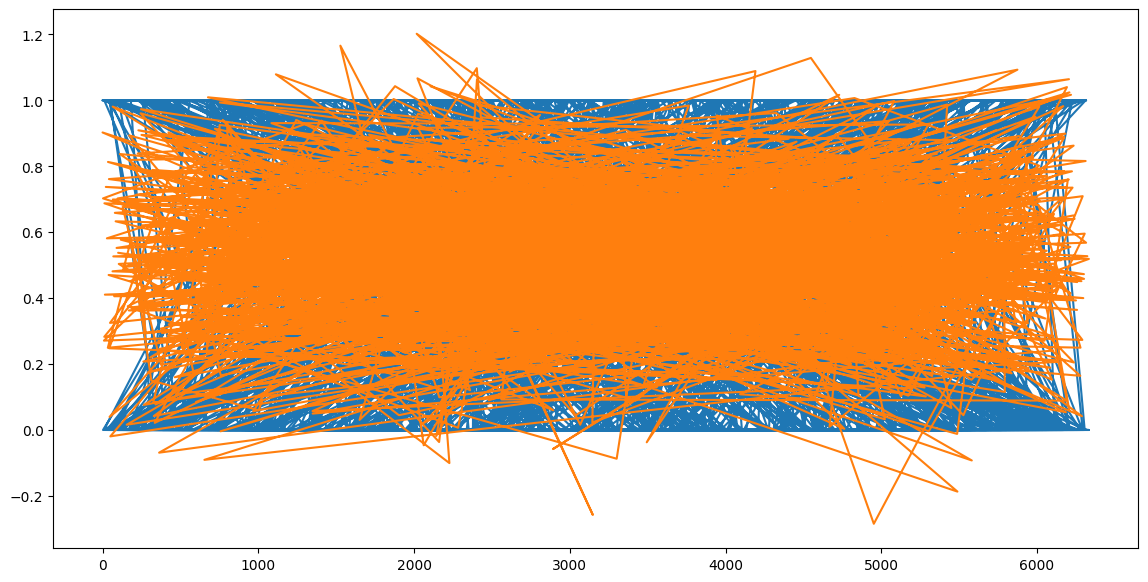

In [ ]:
#Regressor
reg = xgb.XGBRegressor(objective="reg:squarederror")
reg.fit(X_train, y_train)

preds_reg = reg.predict(X_test)
metrics_xgb_reg = calculate_metrics(y_test, preds_reg)
print("XGBoost Regressor Metrics:")
print_metrics(metrics_xgb_reg)


plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test.values, label="Teste")
plt.plot(y_test.index, preds_reg, label="XGBoost Predições")

# XGClass

Acurácia: 36.67%


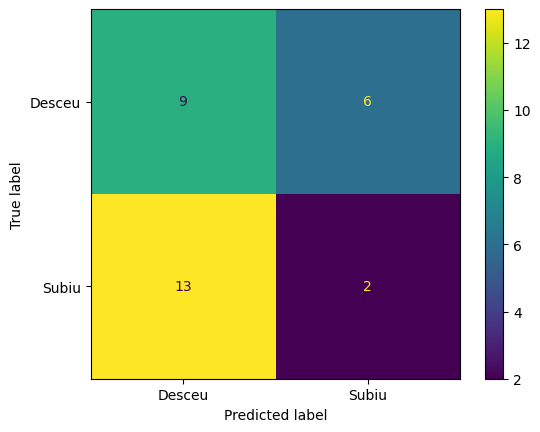

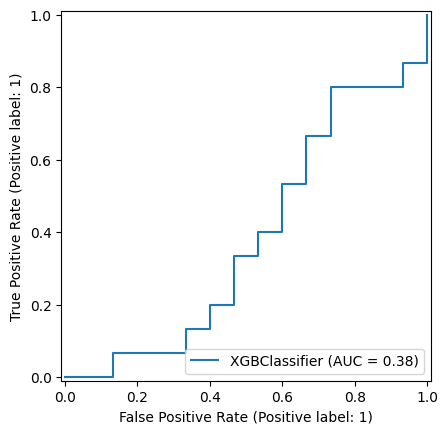

In [17]:
xgb_class = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

xgb_class.fit(X_train, y_train)
y_pred = xgb_class.predict(X_test)

acc_xgbC = accuracy_score(y_test, y_pred)
print(f"Acurácia: {acc_xgbC*100:.2f}%")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Desceu", "Subiu"])
disp.plot()
plt.show()

RocCurveDisplay.from_estimator(xgb_class, X_test, y_test)

# Prophet

In [120]:
train_prophet = train.rename(columns={"Data": "ds", "Último": "y"})
test_prophet = test.rename(columns={"Data": "ds", "Último": "y"})

model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True, )
model.add_regressor("Abertura")
model.fit(train_prophet)

future = model.make_future_dataframe(periods=len(test))
future["Abertura"] = pd.concat([train["Abertura"], test["Abertura"]], ignore_index=True)
forecast = model.predict(future)

preds = forecast[["ds", "yhat"]].tail(len(test))
preds = preds.set_index("ds")
y_test = test_prophet.set_index("ds")["y"]

metrics_pr = calculate_metrics(y_test, preds["yhat"])
print("Prophet Metrics:")
print_metrics(metrics_pr)

pred_direction = (preds["yhat"] >= 0.5).astype(int).reset_index(drop=True)
real_direction = y_test.astype(int).reset_index(drop=True)

acc_proph = (real_direction == pred_direction).mean()

print(f"Acurácia Direcional Prophet: {acc_proph:.2%}")

21:08:54 - cmdstanpy - INFO - Chain [1] start processing
21:08:56 - cmdstanpy - INFO - Chain [1] done processing


Prophet Metrics:
MAE: 2247.6135505820794
MSE: 11652355.220488971
MAPE: 1.62 %
Acurácia Direcional Prophet: 0.00%


# SARIMAX

In [ ]:
exog_train = train[["Direção"]]
exog_test = test[["Direção"]]

model = sm.tsa.statespace.SARIMAX(
    train["Target"],
    exog=exog_train,
    order=(
        p,
        d,
        1, # Diminuir o "q" para otimizar processamento
    ),  
    seasonal_order=(0, 0, 0, 12),
)

results = model.fit()

preds = results.get_forecast(steps=len(test), exog=exog_test).predicted_mean

metrics_sarimax = calculate_metrics(test["Target"], preds)
print("SARIMAX Metrics:")
print_metrics(metrics_sarimax)

acc_smx = (y_test.reset_index(drop=True) == preds_clf).mean()

print(f"Acurácia de direção: {acc_smx:.2%}")

SARIMAX Metrics:
MAE: 0.5022818778990863
MSE: 0.25310997101896515
MAPE: 126577930610857568.00 %
Acurácia de direção: 43.33%


# Resultados

In [116]:
pred_sarimax = preds
pred_prophet = forecast["yhat"].tail(len(test))
pred_xgboost = reg.predict(X_test)

NameError: name 'pred_sarimax' is not defined

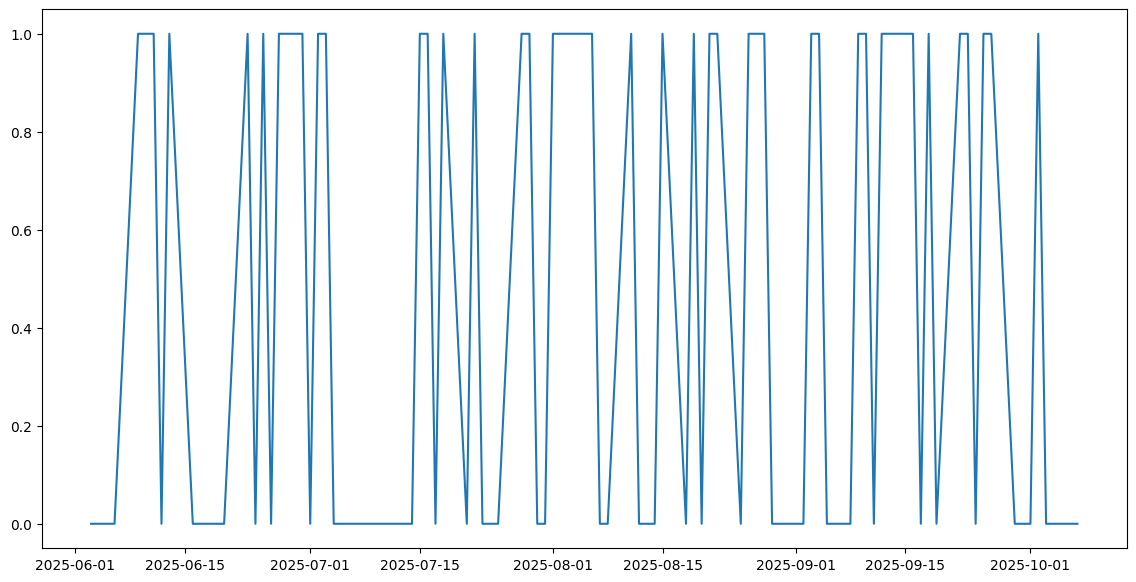

In [70]:
plt.figure(figsize=(14, 7))
plt.plot(test["Data"], test["Target"], label="Teste")
plt.plot(test["Data"], pred_sarimax, label="SARIMAX Predições")
plt.plot(test["Data"], pred_xgboost, label="XGBoost Predições")
plt.plot(test_prophet["ds"], pred_prophet, label="Prophet Predições")
plt.title("Previsões dos Modelos")
plt.xlabel("Data")
plt.ylabel("Preço de Fechamento")
#plt.ylim(bottom=125000)
plt.legend()

In [104]:
df = pd.DataFrame(
    [metrics_xgb_clf, metrics_pr, metrics_sarimax],
    columns=["MAE", "MSE", "MAPE"],
    index=["XGBoost", "Prophet", "SARIMAX"],
)
df.sort_values(by="MAPE", ascending=True).applymap(lambda x: f"{x:0.2f}" if isinstance(x, (int, float)) else x)

,MAE,MSE,MAPE
XGBoost,0.03,0.03,15011998757901654.00
SARIMAX,0.50,0.25,114631928655318304.00
Prophet,0.51,0.26,117482476170363568.00


In [ ]:
x = ibov[["delta", "mm_14", "dif_mm3", "Var"]]
y = ibov["Target"]

train_size = ibov.shape[0] - 30
X_train = x[:train_size]
X_test = x[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Base Treinamento \nSubiu:", list(y_train).count(1), " Desceu:", list(y_train).count(0), "\nBase Testes \nSubiu:", list(y_test).count(1), " Desceu:", list(y_test).count(0))


Base Treinamento 
Subiu: 3269  Desceu: 3047 
Base Testes 
Subiu: 15  Desceu: 15


# LogReg

Acurácia Regressão Logística: 48.89%

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.50      0.74      0.60        23
           1       0.45      0.23      0.30        22

    accuracy                           0.49        45
   macro avg       0.48      0.48      0.45        45
weighted avg       0.48      0.49      0.45        45


Matriz de Confusão:
 [[17  6]
 [17  5]]


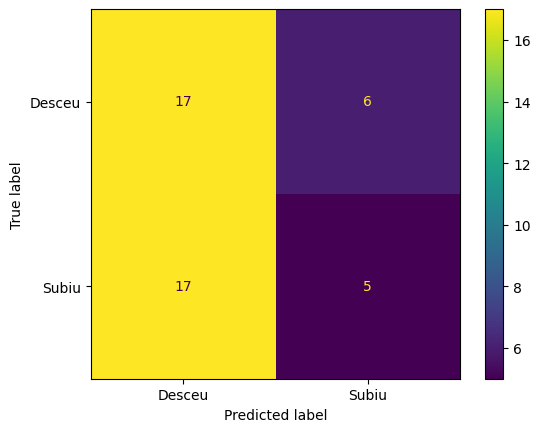

In [30]:
logreg = LogisticRegression(max_iter=2000, random_state=30, class_weight='balanced')
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

acc_logreg = logreg.score(X_test, y_test)
print(f"Acurácia Regressão Logística: {acc_logreg*100:.2f}%")
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))
print("\nMatriz de Confusão:\n", confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Desceu", "Subiu"])
disp.plot()
plt.show()

# Testes com Z-Score

In [98]:
zcorte = 3.5

media_var = X_train['Var%'].mean()
std_var = X_train['Var%'].std()

lower_edge = media_var - (zcorte * std_var)
upper_edge = media_var + (zcorte * std_var)

X_train['Var%Cap'] = np.where(
    X_train['Var%'] > upper_edge, upper_edge,
    np.where(X_train['Var%'] < lower_edge, lower_edge, X_train['Var%'])
)

X_test['Var%Cap'] = np.where(
    X_test['Var%'] > upper_edge, upper_edge,
    np.where(X_test['Var%'] < lower_edge, lower_edge, X_test['Var%'])
)

X_train_ordenado = X_train.sort_values(by='Var%Cap', ascending=True)

X_train.drop(columns=['Var%'], inplace=True) 
X_test.drop(columns=['Var%'], inplace=True)

X_test.head()

,year,month,day,dayofweek,Abertura,daily_return,Vol.,mm_3,mm_7,mm_14,mm_21,mm_30,vol_5,vol_10,vol_20,dif_mm3,Último,Var%Cap
6256,2025,6,3,1,136787.0,NaN,9.700000e+09,137120.000000,138065.571429,138407.428571,137681.476190,136570.366667,922.118376,858.490930,1563.202108,426.000000,137546.0,0.56
6257,2025,6,4,2,137547.0,0.005549,1.020000e+10,137111.666667,137903.571429,138240.857143,137847.476190,136788.300000,703.279958,909.130451,1178.564179,-109.666667,137002.0,-0.40
6258,2025,6,5,3,137003.0,-0.003962,9.480000e+09,136928.000000,137431.428571,138030.071429,137982.619048,136922.300000,473.178930,1033.614096,1178.236161,-692.000000,136236.0,-0.56
6259,2025,6,6,4,136236.0,-0.005598,9.120000e+09,136446.666667,137033.428571,137777.642857,137976.428571,136973.033333,587.665551,1156.448342,1209.914015,-344.666667,136102.0,-0.10
6260,2025,6,9,0,136102.0,-0.000984,7.760000e+09,136012.333333,136628.428571,137462.571429,137937.714286,137005.033333,744.038977,1276.757856,1279.227747,-313.333333,135699.0,-0.30


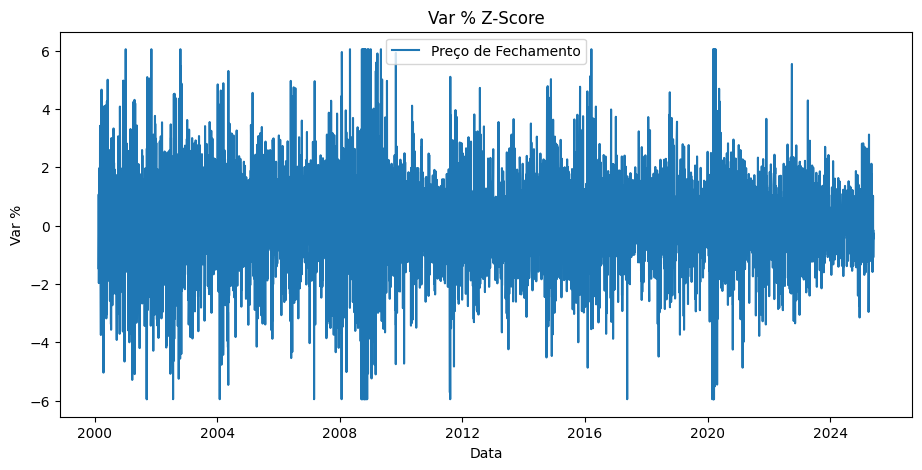

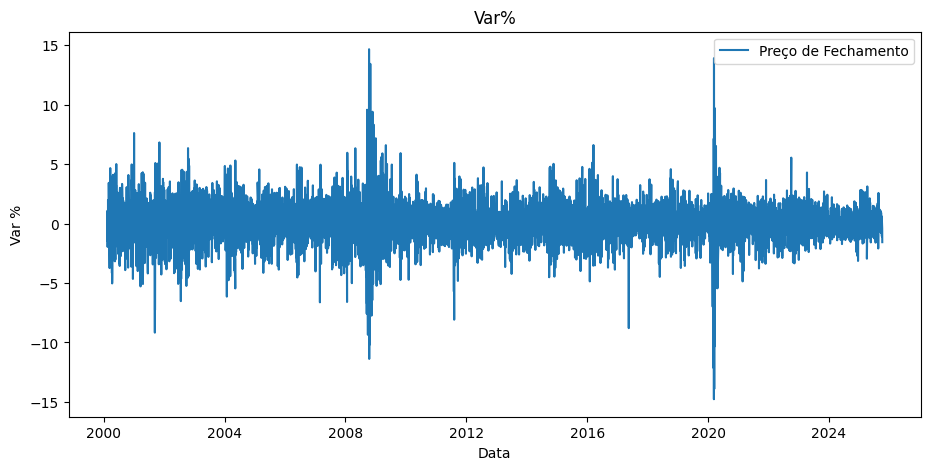

In [ ]:
plt.figure(figsize=(11, 5))
plt.plot(X_train['Data'], X_train["Var%Cap"], label="Preço de Fechamento")
plt.title("Var % Z-Score")
plt.xlabel("Data")
plt.ylabel("Var %")
plt.legend()
plt.show()

plt.figure(figsize=(11, 5))
plt.plot(ibov['Data'], ibov["Var%"], label="Preço de Fechamento")
plt.title("Var%")
plt.xlabel("Data")
plt.ylabel("Var %")
plt.legend()
plt.show()

# RF

Acurácia:50.00%

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.50      0.33      0.40        15
           1       0.50      0.67      0.57        15

    accuracy                           0.50        30
   macro avg       0.50      0.50      0.49        30
weighted avg       0.50      0.50      0.49        30

[[ 5 10]
 [ 5 10]]
var_10            0.084505
var_5             0.084196
mm_dados_diff     0.084129
dados_diff_std    0.082447
Vol.              0.082391
var_20            0.081972
dados_diff        0.081574
dif_mn30          0.081452
dif_mn7           0.078724
dif_mn14          0.078720
dif_mn21          0.078537
dif_mn3           0.068155
dayofweek         0.033197
dtype: float64
Balanced Accuracy: 50.00%


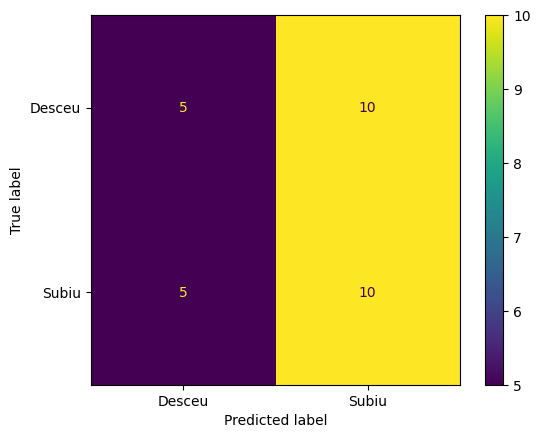

In [197]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    random_state=16
    ,class_weight="balanced_subsample"
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

acuracia_rf = accuracy_score(y_test, y_pred)
print(f"Acurácia:{acuracia_rf*100:.2f}%")
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Desceu", "Subiu"])
disp.plot()

importancias = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print(importancias)

bal_acc = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy: {bal_acc*100:.2f}%")

# Outros Testes (Adfuller)

Text(0.5, 1.0, 'Resíduos')

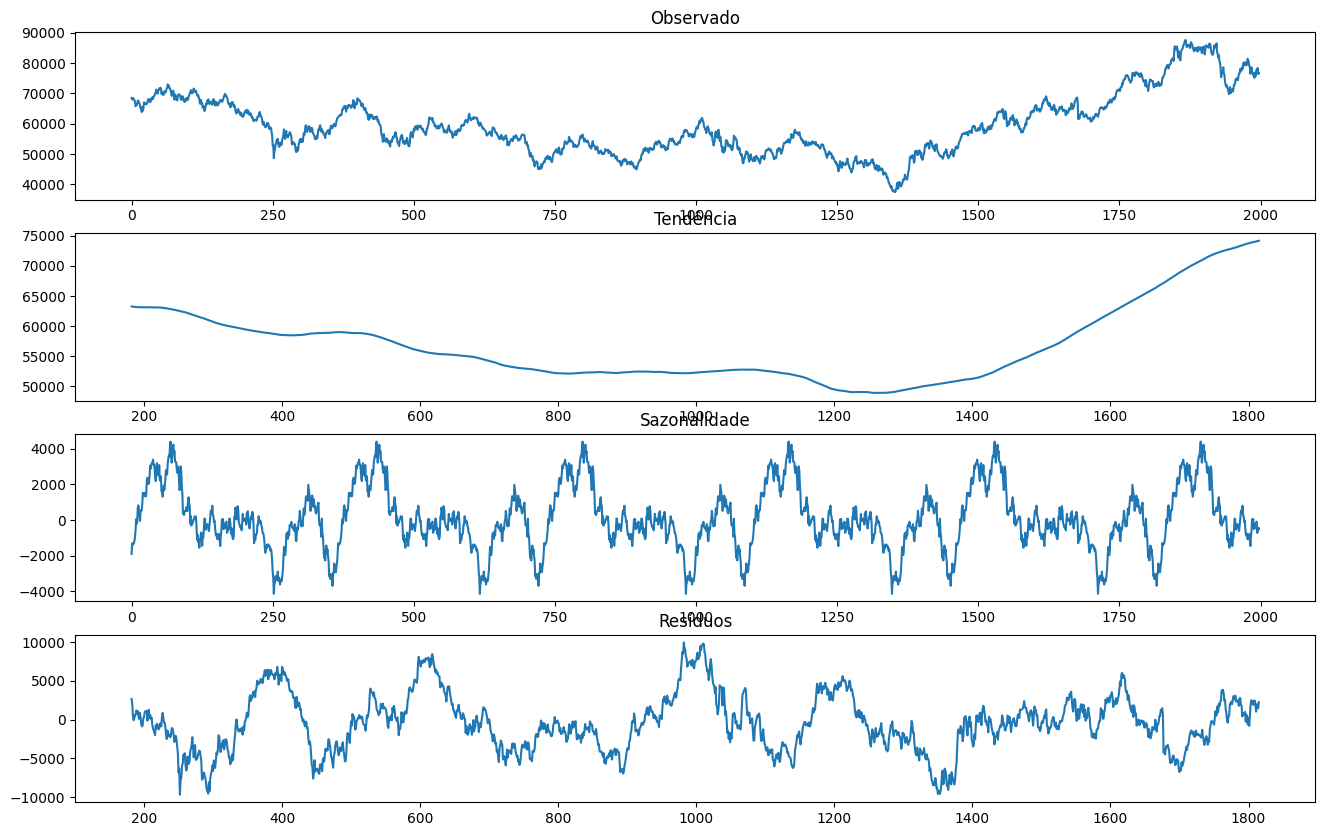

In [61]:
resultados = seasonal_decompose(ibov['Último'], model = 'additive', period = 365)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4,1, figsize=(16,10))

resultados.observed.plot(ax = ax1)
ax1.set_title('Observado')
resultados.trend.plot(ax = ax2)
ax2.set_title('Tendência')
resultados.seasonal.plot(ax = ax3)
ax3.set_title('Sazonalidade')
resultados.resid.plot(ax = ax4)
ax4.set_title('Resíduos')

In [66]:
X = ibov['Último'].values
resultados= adfuller(X)

print('TESTE ADFULLER')
print('Estatística de Teste: %f' % resultados[0])
print('Valor-p: %f' % resultados[1])
print('Valores Críticos:')

for chave, valor in resultados[4].items():
    print('\t%s: %f' % (chave, valor))

TESTE ADFULLER
Estatística de Teste: -1.560183
Valor-p: 0.503558
Valores Críticos:
	1%: -3.433629
	5%: -2.862988
	10%: -2.567541


In [64]:
dados_close_log = np.log(ibov['Último'])
mm_log= dados_close_log.rolling(window=365).mean()
dados_close_s = (dados_close_log - mm_log).dropna()
dados_close_mm = dados_close_s.rolling(window=365).mean()
dados_close_std = dados_close_s.rolling(window=365).std()

X_s = dados_close_s.values
resultados_s = adfuller(X_s)

print('TESTE ADF 2 - LOGARITMICO')
print(f'Teste estatistiico: {resultados_s[0]}')
print(f'Valor-p: {resultados_s[1]}')
print('Valores Críticos:')

for chave, valor in resultados_s[4].items():
    print(f'\t{chave}: {valor}')



TESTE ADF 2 - LOGARITMICO
Teste estatistiico: -2.398787782471036
Valor-p: 0.14207884048052993
Valores Críticos:
	1%: -3.4343607832380814
	5%: -2.8633115295706735
	10%: -2.5677131231763433


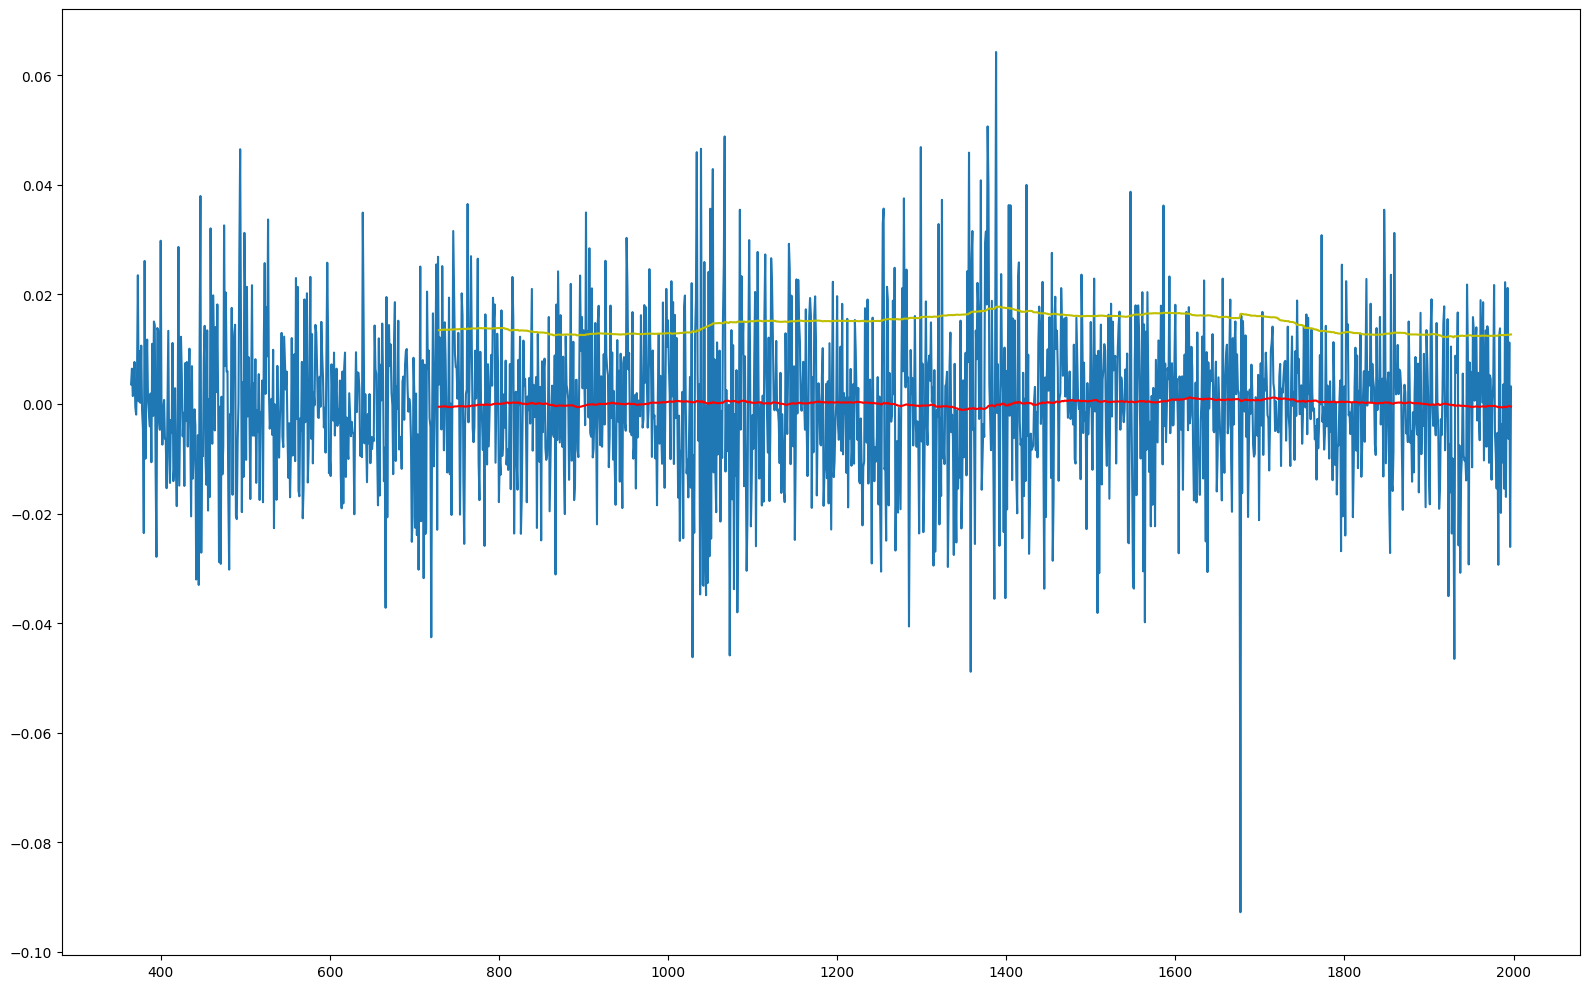

TESTE ADF 3 - DIFERENCIADO
Teste estatistiico: -40.66263273560668
Valor-p: 0.0
Valores Críticos:
	1%: -3.434363244707632
	5%: -2.8633126160514863
	10%: -2.567713701716287


In [67]:
dados_close_diff = dados_close_s.diff(1)
mm_close_diff = dados_close_diff.rolling(365).mean()

dados_close_std_diff = dados_close_diff.rolling(365).std()

f, ax = plt.subplots(figsize=(16,10))
dados_close_diff.plot(ax=ax, legend=False)
mm_close_diff.plot(ax=ax, legend=False, color='r')
dados_close_std_diff.plot(ax=ax, legend=False, color='y')
plt.tight_layout()
plt.show()

X_close_diff = dados_close_diff.dropna().values
resultados_close_diff = adfuller(X_close_diff)

print('TESTE ADF 3 - DIFERENCIADO')
print(f'Teste estatistiico: {resultados_close_diff[0]}')
print(f'Valor-p: {resultados_close_diff[1]}')
print('Valores Críticos:')

for chave, valor in resultados_close_diff[4].items():
    print(f'\t{chave}: {valor}')

# GB

In [37]:
gboost = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, random_state=42)
gboost.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.05
,n_estimators,300
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


Acurácia:53.33%

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.53      0.87      0.66        23
           1       0.57      0.18      0.28        22

    accuracy                           0.53        45
   macro avg       0.55      0.53      0.47        45
weighted avg       0.55      0.53      0.47        45


Matriz de Confusão:
 [[20  3]
 [18  4]]


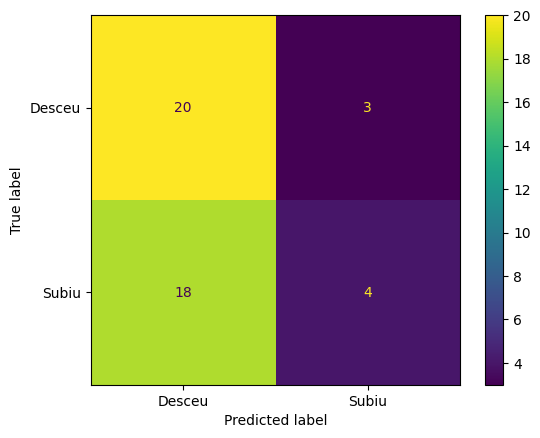

In [38]:
y_pred = gboost.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred)
print(f"Acurácia:{acc_gb*100:.2f}%")
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))
print("\nMatriz de Confusão:\n", confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Desceu", "Subiu"])
disp.plot()
plt.show()


# KNB

In [49]:
KNeigh = KNeighborsClassifier(n_neighbors=1)
KNeigh.fit(X_train, y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


Acurácia:55.56%

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.56      0.61      0.58        23
           1       0.55      0.50      0.52        22

    accuracy                           0.56        45
   macro avg       0.56      0.55      0.55        45
weighted avg       0.56      0.56      0.55        45


Matriz de Confusão:
 [[14  9]
 [11 11]]


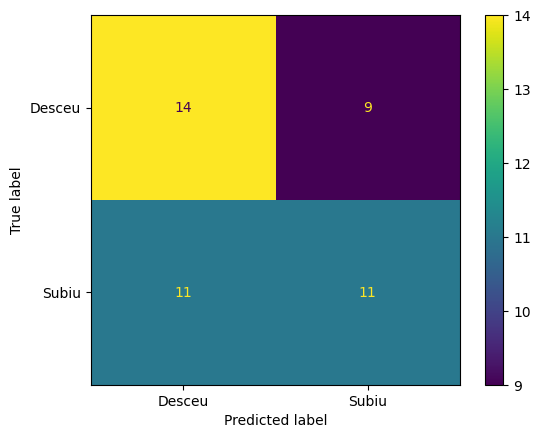

In [50]:
y_pred = KNeigh.predict(X_test)
acc_knb = accuracy_score(y_test, y_pred)
print(f"Acurácia:{acc_knb*100:.2f}%")
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))
print("\nMatriz de Confusão:\n", confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Desceu", "Subiu"])
disp.plot()
plt.show()

# Redes Neurais

In [141]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # saída binária
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

y_pred_proba = model.predict(X_test_scaled).ravel()
y_pred = (y_pred_proba > 0.5).astype(int)

print("Acurácia:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred))

Epoch 1/200


c:\Users\rafae\OneDrive\Documentos\GitHub\Grupo16TechChallenge\Fase 02\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4869 - loss: 0.7212 - val_accuracy: 0.4771 - val_loss: 0.7184
Epoch 2/200
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5200 - loss: 0.6971 - val_accuracy: 0.4889 - val_loss: 0.7068
Epoch 3/200
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5040 - loss: 0.6967 - val_accuracy: 0.5008 - val_loss: 0.7072
Epoch 4/200
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5158 - loss: 0.6948 - val_accuracy: 0.4905 - val_loss: 0.7051
Epoch 5/200
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5115 - loss: 0.6957 - val_accuracy: 0.4984 - val_loss: 0.7031
Epoch 6/200
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5194 - loss: 0.6919 - val_accuracy: 0.4960 - val_loss: 0.7018
Epoch 7/200
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5220 - loss: 0.6943 - val_accuracy: 0.4960 - val_loss: 0.7000
Epoch 8/200
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5146 - loss: 0.6937 - val_accuracy: 0.4953

# GridSearch e LightGBM

In [16]:
lgb = LGBMClassifier(random_state=42, class_weight='balanced')

param_grid = {
    'n_estimators': [200, 400, 800],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 6, 10],
    'num_leaves': [15, 31, 63],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0]
}

grid = GridSearchCV(
    estimator=lgb,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

print("\nMelhores parâmetros encontrados:")
print(grid.best_params_)

# ====== Avaliação ======
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nAcurácia: {acc*100:.2f}%")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))
print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred))

Fitting 3 folds for each of 729 candidates, totalling 2187 fits
[LightGBM] [Info] Number of positive: 3269, number of negative: 3047
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000588 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3570
[LightGBM] [Info] Number of data points in the train set: 6316, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

c:\Users\rafae\OneDrive\Documentos\GitHub\Grupo16TechChallenge\Fase 02\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rafae\OneDrive\Documentos\GitHub\Grupo16TechChallenge\Fase 02\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rafae\OneDrive\Documentos\GitHub\Grupo16TechChallenge\Fase 02\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par


Matriz de Confusão:
 [[15  0]
 [15  0]]


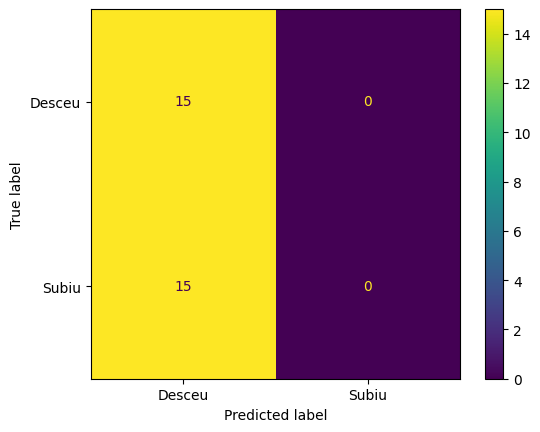

In [27]:
lr_model = LogisticRegression(
    random_state=42,
    solver='liblinear',
    C=2.0,
    max_iter=2000,
    class_weight='balanced'
)

lr_model.fit(X_train, y_train)

y_pred_train = lr_model.predict(X_train)
y_pred_test = lr_model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

test_accuracy

print("\nMatriz de Confusão:\n", confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Desceu", "Subiu"])
disp.plot()
plt.show()


Acurácia: 51.65%

Matriz de Confusão:
 [[ 19 594]
 [ 20 637]]


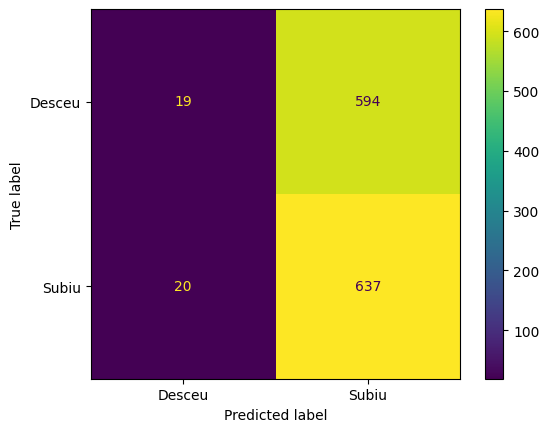

In [80]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.005,
    max_depth=6,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

lgbm_model.fit(X_train, y_train)

y_pred_train = lgbm_model.predict(X_train)

acc = accuracy_score(y_test, y_pred)
print(f"\nAcurácia: {acc*100:.2f}%")
print("\nMatriz de Confusão:\n", confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Desceu", "Subiu"])
disp.plot()
plt.show()

# Grid Search RF

In [ ]:
param_grid = {
    'n_estimators': [100, 250, 400],
    'max_depth': [5, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf = RandomForestClassifier(random_state=16)

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("\n🔎 Melhor combinação de parâmetros:")
print(grid_search.best_params_)
print(f"Melhor balanced_accuracy (treino): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits

🔎 Melhor combinação de parâmetros:
{'class_weight': 'balanced_subsample', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Melhor balanced_accuracy (treino): 0.5122



Acurácia simples: 50.00%
Acurácia balanceada: 50.00%

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.50      1.00      0.67        15
           1       0.00      0.00      0.00        15

    accuracy                           0.50        30
   macro avg       0.25      0.50      0.33        30
weighted avg       0.25      0.50      0.33        30



c:\Users\rafae\OneDrive\Documentos\GitHub\Grupo16TechChallenge\Fase 02\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rafae\OneDrive\Documentos\GitHub\Grupo16TechChallenge\Fase 02\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rafae\OneDrive\Documentos\GitHub\Grupo16TechChallenge\Fase 02\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

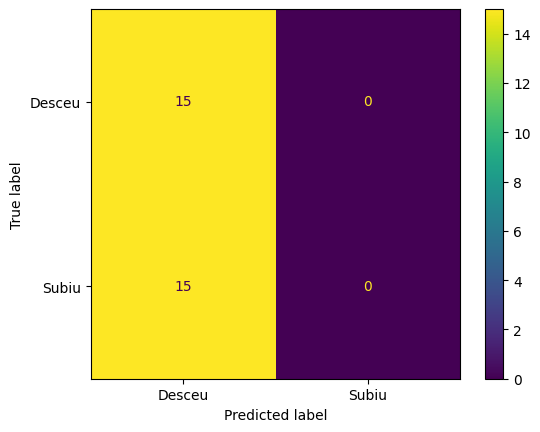

In [65]:
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)
print(f"\nAcurácia simples: {acc*100:.2f}%")
print(f"Acurácia balanceada: {bal_acc*100:.2f}%")

print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Desceu", "Subiu"])
disp.plot()

# GS e CatBoost

In [267]:
tscv = TimeSeriesSplit(n_splits=5)

cat = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='F1',
    random_seed=16,
    verbose=0
)

param_grid = {
    'iterations': [300, 600, 1000],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.03, 0.1],
    'l2_leaf_reg': [1, 3, 5],
    'border_count': [32, 64, 128],
}

param_grid_catb = {
    'subsample': [0.6, 0.8, 1],
    'colsample_bylevel': [0.6, 0.8, 1],
    'random_strength': [1, 3, 5, 8],
    'min_data_in_leaf': [3, 5, 10, 15],
    'scale_pos_weight': [0.8, 1, 1.2]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=catb,
    param_grid=param_grid_catb,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("\nMelhores parâmetros encontrados:")
print(grid.best_params_)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits

Melhores parâmetros encontrados:
{'colsample_bylevel': 1, 'min_data_in_leaf': 15, 'random_strength': 1, 'scale_pos_weight': 1, 'subsample': 0.6}



Acurácia: 50.00%

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.50      0.27      0.35        15
           1       0.50      0.73      0.59        15

    accuracy                           0.50        30
   macro avg       0.50      0.50      0.47        30
weighted avg       0.50      0.50      0.47        30



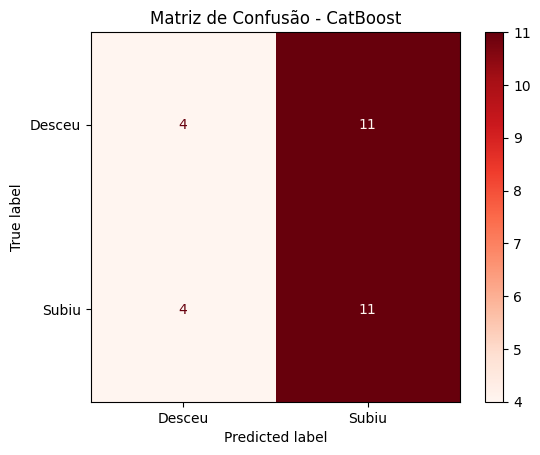


Importância das variáveis:
 dif_mn30       10.401832
dif_mn3        10.061144
dayofweek       9.003171
mm_diff         8.938859
var_20          7.786637
var_5           7.678818
dif_mn21        7.285388
dif_mn7         7.162686
std_diff        7.015816
var_10          6.997110
dif_mn14        6.205451
diff_ultimo     5.860681
Vol.            5.602407
dtype: float64


In [276]:
catb = CatBoostClassifier(
    iterations=300,
    depth=4,
    learning_rate=0.01,
    eval_metric="Accuracy",
    loss_function='Logloss',
    random_seed=42,
    border_count=32,
    l2_leaf_reg=5,
    verbose=0,
    scale_pos_weight=0.96,
    grow_policy='Lossguide',
    thread_count=-1,
    colsample_bylevel=1,
    min_data_in_leaf=15,
    subsample=0.6
    )

catb.fit(X_train, y_train)

y_pred = catb.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\nAcurácia: {acc*100:.2f}%")
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Desceu", "Subiu"])
disp.plot(cmap="Reds")
plt.title("Matriz de Confusão - CatBoost")
plt.show()

importancias = pd.Series(catb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nImportância das variáveis:\n", importancias)